**CreditWise Loan System**

**Problem Statement**

A mid-sized financial company named offers personal and
home loans to customers across urban and rural regions of India. Every day,
hundreds of customers apply for loans through online and branch applications.

SecureTrust Bank

Until now, SecureTrust Bank has been using a where
loan officers evaluate applications by checking income proofs, employment
details, credit history, and other documents. This process is time-consuming,
biased & inconsistent.

manual verification process

As a result, the bank faces two major challenges:
1. Good customers sometimes get rejected, leading to loss of business.
2. High-risk customers sometimes get approved, leading to financial losses.

To solve this problem, the bank wants to introduce an
powered by Machine Learning that can automatically analyse applicant
details and before final
human verification.

**Suryavhi Das**  is hired as a **ML Engineer** to design and develop this
intelligent system using historical loan application data. The system must learn
hidden patterns from previous customer records and provide accurate, fast, and
unbiased loan approval decisions.

Importing libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing the dataset:

In [2]:
df= pd.read_csv('loan_approval_data.csv')
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [3]:
data=df.copy()

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    str    
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    str    
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    str    
 15  Property_Area       950 non-null    str    
 16  Education_Level   

In [19]:
df.columns

Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income',
       'Employment_Status', 'Age', 'Marital_Status', 'Dependents',
       'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term', 'Loan_Purpose',
       'Property_Area', 'Education_Level', 'Gender', 'Employer_Category',
       'Loan_Approved'],
      dtype='str')

EDA & Data Pre-Processing:

In [5]:
# Checking for null values:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

Null Valus Exist

In [6]:
#checking for duplicate values:
df.duplicated().sum().sum()

np.int64(0)

There are no duplicate values.

In [7]:
data.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


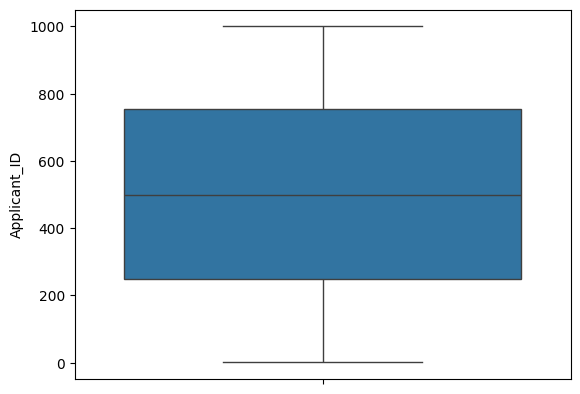

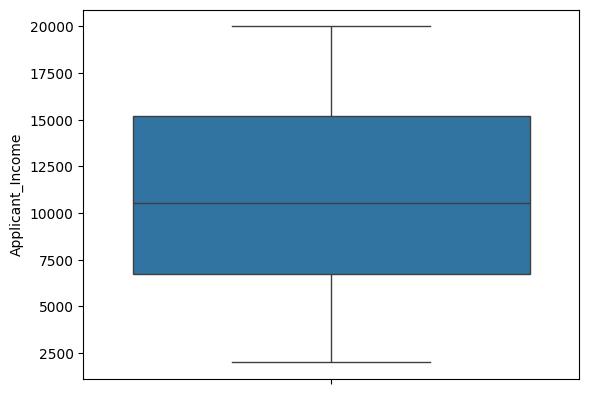

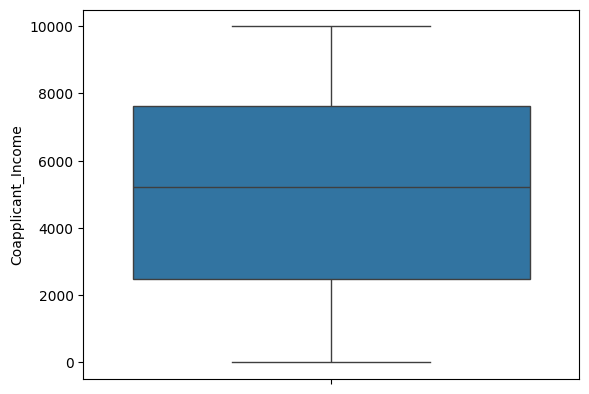

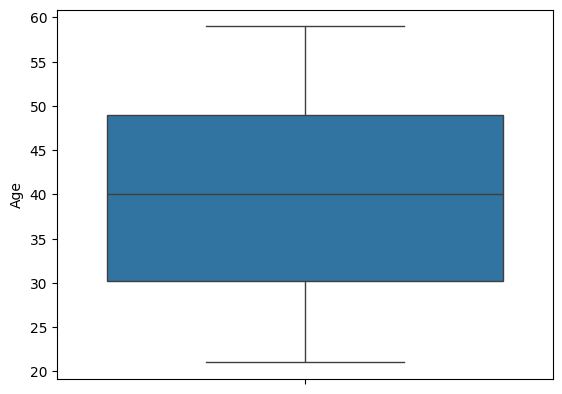

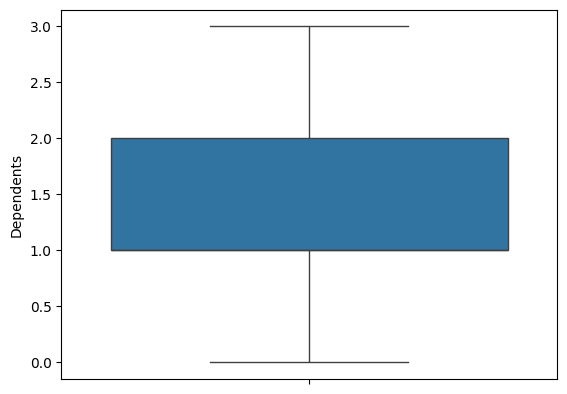

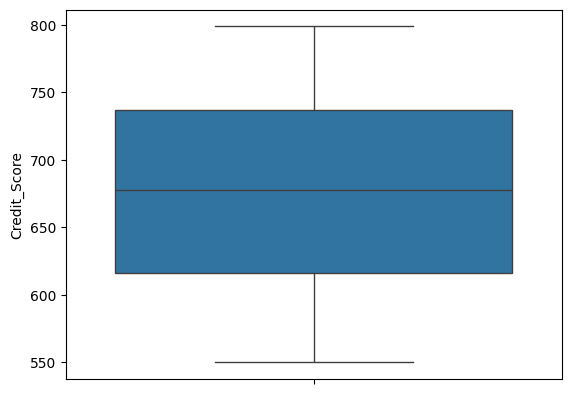

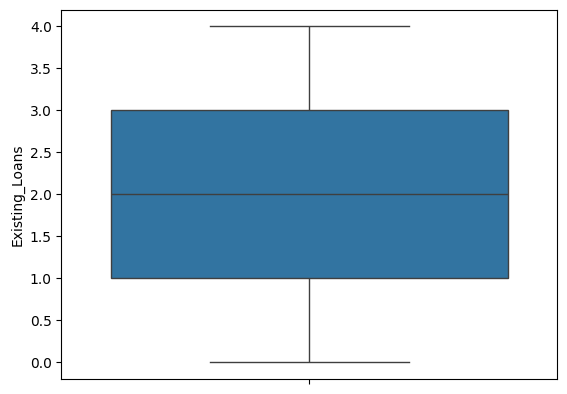

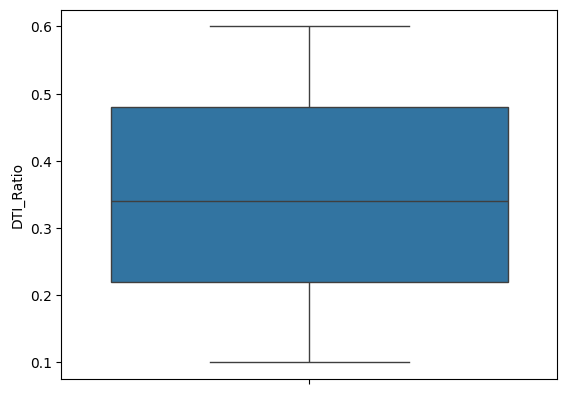

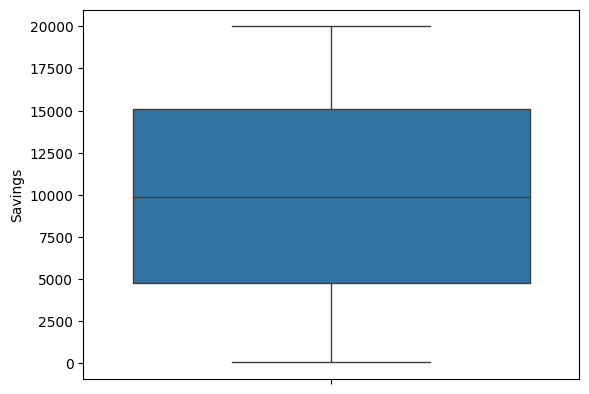

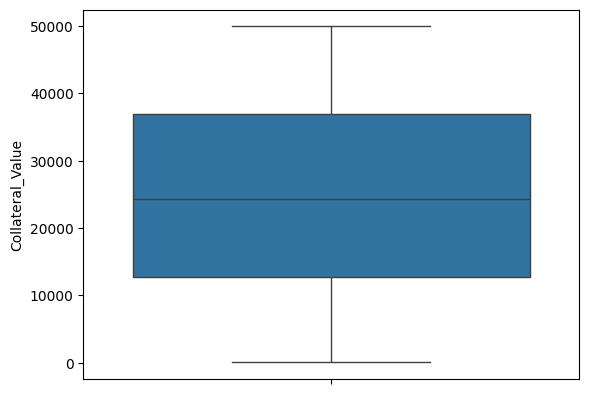

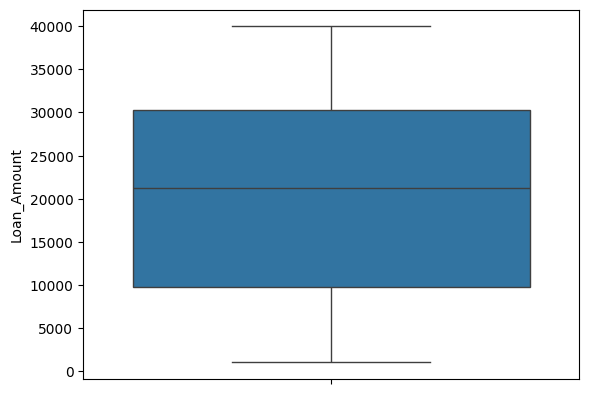

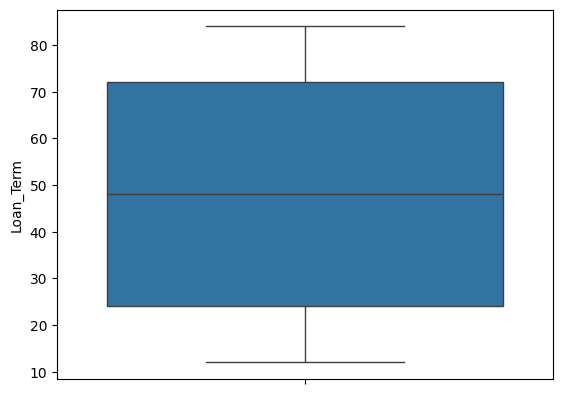

In [ ]:
for col in df.columns:
  if df[col].dtypes != 'object':
    sns.boxplot(df[col])
    plt.show()

Less Outliers.

In [ ]:
for col in df.columns:
  if df[col].dtypes == 'object':
    print(df[col].value_counts())
    print("-"*50)

Employment_Status
Salaried         465
Contract         213
Self-employed    182
Unemployed        90
Name: count, dtype: int64
--------------------------------------------------
Marital_Status
Married    593
Single     357
Name: count, dtype: int64
--------------------------------------------------
Loan_Purpose
Business     202
Car          199
Home         190
Education    181
Personal     178
Name: count, dtype: int64
--------------------------------------------------
Property_Area
Urban        467
Rural        294
Semiurban    189
Name: count, dtype: int64
--------------------------------------------------
Education_Level
Graduate        672
Not Graduate    278
Name: count, dtype: int64
--------------------------------------------------
Gender
Male      571
Female    379
Name: count, dtype: int64
--------------------------------------------------
Employer_Category
Private       372
Government    202
MNC           144
Business      135
Unemployed     97
Name: count, dtype: int64
---

# Null values are present.
# No duplicate values.
# No type error.
# No Ourliers exists into the dataset.
# No formatting issues.

In [11]:
print(df.select_dtypes(include='object').columns)
print('--'*60)
print(df.select_dtypes(include='number').columns)

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category', 'Loan_Approved'],
      dtype='object')
------------------------------------------------------------------------------------------------------------------------
Index(['Applicant_ID', 'Applicant_Income', 'Coapplicant_Income', 'Age',
       'Dependents', 'Credit_Score', 'Existing_Loans', 'DTI_Ratio', 'Savings',
       'Collateral_Value', 'Loan_Amount', 'Loan_Term'],
      dtype='object')


In [9]:
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Handling null values:
categorical_cols=df.select_dtypes(include='object').columns
categorical_cols

neumerical_cols=df.select_dtypes(include='number').columns
neumerical_cols

from sklearn.impute import SimpleImputer # generally used to fill null values.

imputer1= SimpleImputer(strategy='mean')

df[neumerical_cols]=imputer1.fit_transform(df[neumerical_cols])

imputer2= SimpleImputer(strategy="most_frequent")

df[categorical_cols]=imputer2.fit_transform(df[categorical_cols])

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   str    
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   str    
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   str    
 15  Property_Area       1000 non-null   str    
 16  Education_Level   

Now there are no missing values inside dataset.


# EDA:

1. Distribution of Loan Approved and rejected candidates.

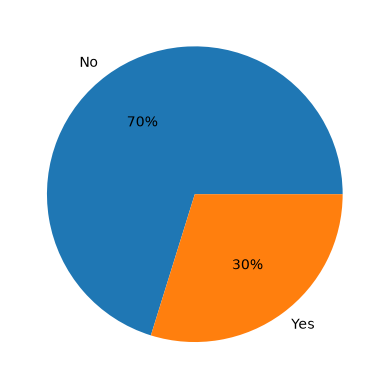

In [12]:
Loan_Class= df['Loan_Approved'].value_counts().reset_index()
plt.pie(Loan_Class['count'],labels=Loan_Class['Loan_Approved'],autopct="%0.f%%")

2. Distribution of gender

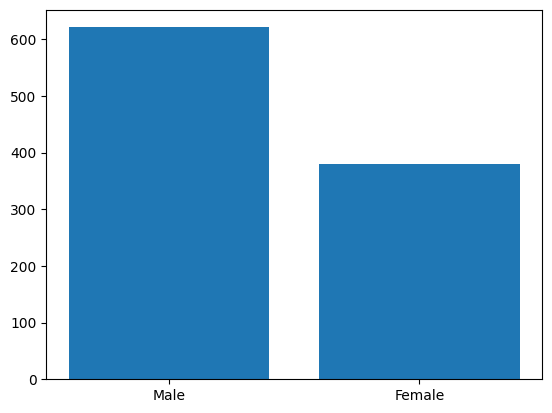

In [22]:
Gender_Distribution= df['Gender'].value_counts().reset_index()
plt.bar(Gender_Distribution['Gender'],Gender_Distribution['count'])
plt.show()

3. Frequecy checking according to education level.

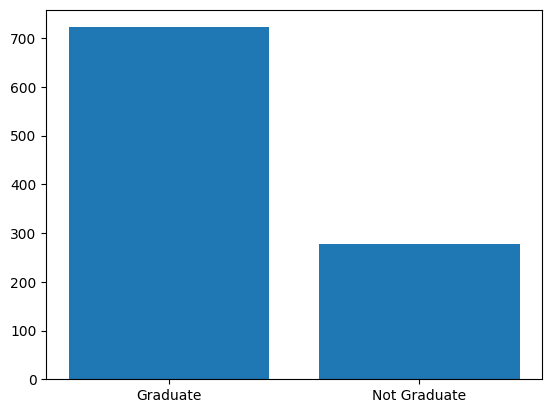

In [24]:
education_Distribution= df['Education_Level'].value_counts().reset_index()
plt.bar(education_Distribution['Education_Level'],education_Distribution['count'])
plt.show()

In [31]:
df.describe(include='all')

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
count,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000,1000,1000
unique,NaN,NaN,NaN,4,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,3,2,2,5,2
top,NaN,NaN,NaN,Salaried,NaN,Married,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Business,Urban,Graduate,Male,Private,No
freq,NaN,NaN,NaN,515,NaN,643,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,252,517,722,621,422,702
mean,501.220000,10852.571579,5082.455789,NaN,39.971579,NaN,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000,NaN,NaN,NaN,NaN,NaN,NaN
std,282.267965,4933.339492,2868.563488,NaN,10.857445,NaN,1.077058,69.537662,1.370603,0.140683,5712.189236,13982.086562,11212.555805,23.630794,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,2009.000000,1.000000,NaN,21.000000,NaN,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,262.750000,6857.000000,2701.250000,NaN,31.000000,NaN,1.000000,618.000000,1.000000,0.230000,4964.000000,13166.000000,10478.250000,24.000000,NaN,NaN,NaN,NaN,NaN,NaN
50%,501.220000,10852.571579,5082.455789,NaN,39.971579,NaN,1.237368,676.033684,2.000000,0.347263,9940.452632,24802.792632,20522.825263,48.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,738.250000,14973.250000,7452.750000,NaN,49.000000,NaN,2.000000,735.000000,3.000000,0.470000,14784.750000,36396.000000,29683.250000,72.000000,NaN,NaN,NaN,NaN,NaN,NaN


4. Which type of employees apply more for loan, and got rejections?

In [40]:
df.groupby('Employer_Category')['Loan_Approved'].count()

,Loan_Approved
Employer_Category,
Business,135
Government,202
MNC,144
Private,422
Unemployed,97


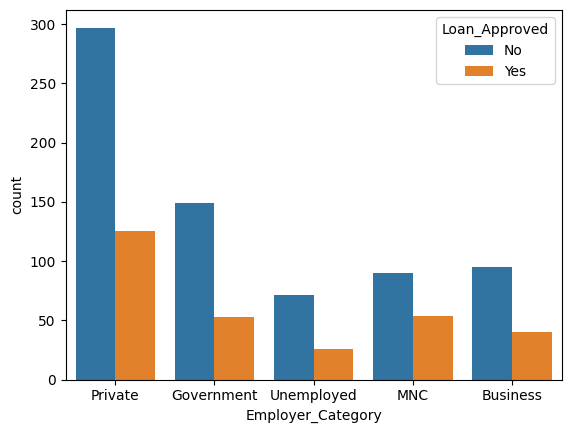

In [42]:
sns.countplot(data=df,x='Employer_Category',hue='Loan_Approved')
plt.show()

5. Frequency distribution according to Employement status.

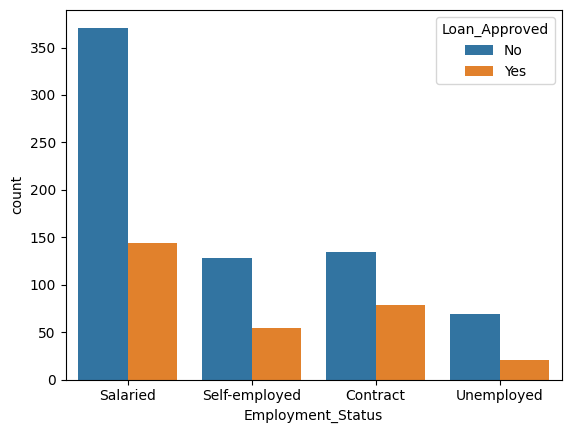

In [43]:
sns.countplot(data=df,x='Employment_Status',hue='Loan_Approved')
plt.show()

6. Loan application based marital staus.

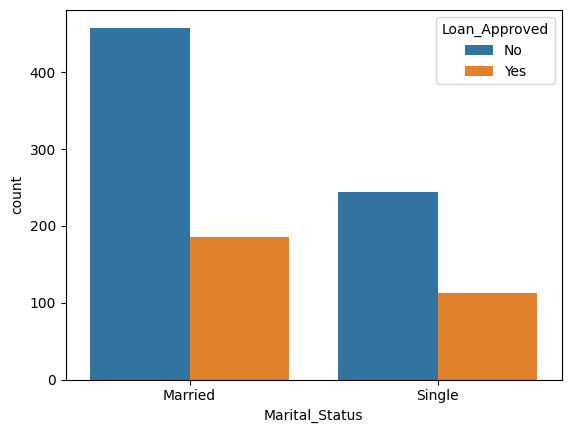

In [44]:
sns.countplot(data=df,x='Marital_Status',hue='Loan_Approved')
plt.show()

7. Application status based on property_area.

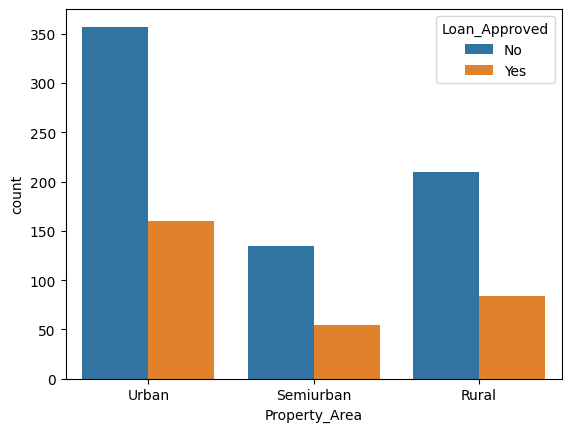

In [45]:
sns.countplot(data=df,x='Property_Area',hue='Loan_Approved')
plt.show()

8. Critical thresholds to understand loan approval patterns.

In [36]:
print("Average income of approved applicants", df[df['Loan_Approved']=='Yes']['Applicant_Income'].mean())
print("Average income of rejected applicants", df[df['Loan_Approved']=='No']['Applicant_Income'].mean())

Average income of approved applicants 11759.197513246203
Average income of rejected applicants 10467.707578347578


In [37]:
print("Average Credit Score of approved applicants", df[df['Loan_Approved']=='Yes']['Credit_Score'].mean())
print("Average Credit Score of rejected applicants", df[df['Loan_Approved']=='No']['Credit_Score'].mean())

Average Credit Score of approved applicants 724.1628823737195
Average Credit Score of rejected applicants 655.6027710301395


In [38]:
print("Average Loan Amount of approved applicants", df[df['Loan_Approved']=='Yes']['Loan_Amount'].mean())
print("Average Loan Amount of rejected applicants", df[df['Loan_Approved']=='No']['Loan_Amount'].mean())

Average Loan Amount of approved applicants 18346.94816672554
Average Loan Amount of rejected applicants 21446.488190133452


In [54]:
print("Average DTI of approved applicants", df[df['Loan_Approved']==1]['DTI_Ratio'].mean())
print("Average DTI of rejected applicants", df[df['Loan_Approved']==0]['DTI_Ratio'].mean())

Average DTI of approved applicants 0.25127163546450015
Average DTI of rejected applicants 0.3880116959064328


In [ ]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [50]:
map={
    'Yes':1,
    'No':0
}

df['Loan_Approved']= df['Loan_Approved'].map(map)

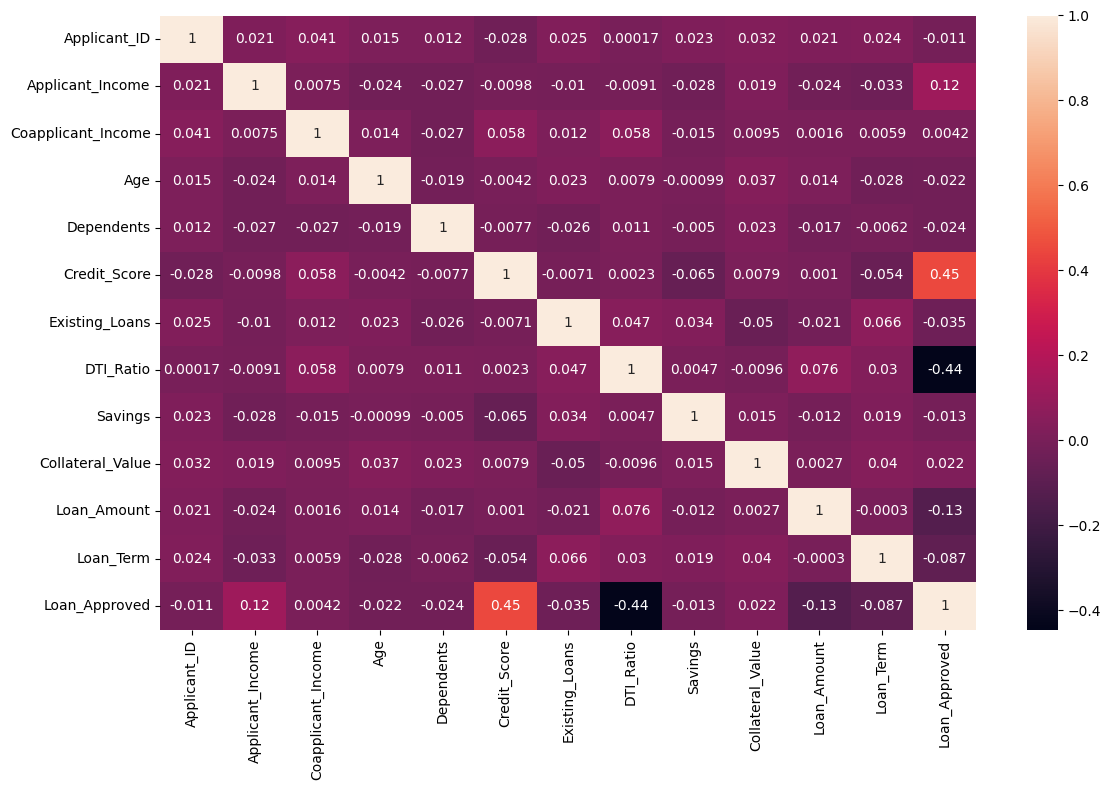

In [51]:
neumerical_cols=df.select_dtypes(include='number').columns
neumerical_cols


plt.figure(figsize=(12,8))
matrix= df[neumerical_cols].corr()
sns.heatmap(matrix, annot=True)
plt.tight_layout()
plt.show()

# Feature Engineering:

Selecting Important Columns that actually matters for Loan Approval.

In [13]:
columns_to_drop = ['Collateral_Value', 'Coapplicant_Income', 'Applicant_ID', 'Savings', 'Age', 'Dependents', 'Existing_Loans', 'Loan_Term', 'Loan_Amount']

X = df.drop(columns=columns_to_drop + ['Loan_Approved'])
y = df['Loan_Approved']

In [21]:
X.columns

Index(['Applicant_Income', 'Employment_Status', 'Marital_Status',
       'Credit_Score', 'DTI_Ratio', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category'],
      dtype='str')

In [14]:
X.head()

,Applicant_Income,Employment_Status,Marital_Status,Credit_Score,DTI_Ratio,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category
0,17795.0,Salaried,Married,637.0,0.53,Personal,Urban,Not Graduate,Female,Private
1,2860.0,Salaried,Married,621.0,0.30,Car,Semiurban,Graduate,Male,Private
2,7390.0,Salaried,Single,674.0,0.20,Business,Urban,Graduate,Female,Government
3,13964.0,Salaried,Married,579.0,0.31,Business,Rural,Graduate,Female,Government
4,13284.0,Self-employed,Single,721.0,0.29,Car,Urban,Graduate,Male,Private


In [15]:
cat_columns= X.select_dtypes(include='object').columns
cat_columns

Index(['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category'],
      dtype='str')

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state= 42)

# Training:



In [17]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression

ohe= OneHotEncoder()
ohe.fit(X[cat_columns])
column_trans=make_column_transformer((OneHotEncoder(categories=ohe.categories_),['Employment_Status', 'Marital_Status', 'Loan_Purpose', 'Property_Area',
       'Education_Level', 'Gender', 'Employer_Category']),
                                    remainder='passthrough')

model= LogisticRegression()
pipe= make_pipeline(column_trans,model)

In [18]:
import warnings
warnings.filterwarnings('ignore')

pipe.fit(x_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['No','Yes']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Applicant_Income','Employment_Status','Marital_Status',..., 'Education_Level','Gender','Employer_Category']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of

In [22]:
score= pipe.score(x_test,y_test)
print("Score:",score)

Score: 0.825


# Optimal Model Finding:


In [73]:
# Import the required classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Define your dictionary of models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# List to store metrics for each model
metrics_list = []

# 2. Run the iterative training and evaluation loop
for model_name, model_instance in models.items():
    # Dynamically build the pipeline with your pre-defined column_trans
    pipe = make_pipeline(column_trans, model_instance)

    # Train the pipeline
    pipe.fit(x_train, y_train)

    # Make predictions
    y_pred = pipe.predict(x_test)

    # Calculate performance metrics (using average='macro' for safety with multi-class)
    metrics_list.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1 Score': f1_score(y_test, y_pred, average='macro')
    })

# 3. Create the comparative DataFrame and sort by the best performer
df_metrics = pd.DataFrame(metrics_list)
df_metrics = df_metrics.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# View the final performance board
print(df_metrics)


                 Model  Accuracy  Precision    Recall  F1 Score
0        Random Forest     0.890   0.870268  0.870268  0.870268
1        Decision Tree     0.885   0.858791  0.885069  0.869463
2    Gradient Boosting     0.875   0.849050  0.864076  0.855787
3  Logistic Regression     0.825   0.800676  0.772910  0.784157


Interms for Precision and Accuracy Random Forest is best.

Try to Imporove the model Performance:


In [76]:
X['DTI_Ratio']= X['DTI_Ratio']*2
X['Credit_Score']= X['Credit_Score']*2

x_train,x_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state= 42)
# 1. Define your dictionary of models
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

# List to store metrics for each model
metrics_list = []

# 2. Run the iterative training and evaluation loop
for model_name, model_instance in models.items():
    # Dynamically build the pipeline with your pre-defined column_trans
    pipe = make_pipeline(column_trans, model_instance)

    # Train the pipeline
    pipe.fit(x_train, y_train)

    # Make predictions
    y_pred = pipe.predict(x_test)

    # Calculate performance metrics (using average='macro' for safety with multi-class)
    metrics_list.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, average='macro'),
        'Recall': recall_score(y_test, y_pred, average='macro'),
        'F1 Score': f1_score(y_test, y_pred, average='macro')
    })

# 3. Create the comparative DataFrame and sort by the best performer
df_metrics = pd.DataFrame(metrics_list)
df_metrics = df_metrics.sort_values(by='F1 Score', ascending=False).reset_index(drop=True)

# View the final performance board
print(df_metrics)


                 Model  Accuracy  Precision    Recall  F1 Score
0        Random Forest     0.890   0.870268  0.870268  0.870268
1        Decision Tree     0.885   0.858791  0.885069  0.869463
2    Gradient Boosting     0.875   0.849050  0.864076  0.855787
3  Logistic Regression     0.875   0.853571  0.850277  0.851891


Not that much of improvement.

# Model Saving For deployment:

In [37]:
X = df.drop(columns=columns_to_drop + ['Loan_Approved'])
y = df['Loan_Approved']

y = y.map({'Yes': 1, 'No': 0})

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [38]:
X.head()

,Applicant_Income,Employment_Status,Marital_Status,Credit_Score,DTI_Ratio,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category
0,17795.0,Salaried,Married,637.0,0.53,Personal,Urban,Not Graduate,Female,Private
1,2860.0,Salaried,Married,621.0,0.30,Car,Semiurban,Graduate,Male,Private
2,7390.0,Salaried,Single,674.0,0.20,Business,Urban,Graduate,Female,Government
3,13964.0,Salaried,Married,579.0,0.31,Business,Rural,Graduate,Female,Government
4,13284.0,Self-employed,Single,721.0,0.29,Car,Urban,Graduate,Male,Private


In [39]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [40]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=42)
pipe= make_pipeline(column_trans,model)

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

In [41]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Accuracy:",accuracy_score(y_test,y_pred))
print("Precision:",precision_score(y_test,y_pred))
print("Recall:",recall_score(y_test,y_pred))

Accuracy: 0.89
Precision: 0.819672131147541
Recall: 0.819672131147541


Hyper Parameter Tuning to get best Random Forest Model:


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score

# 1. Initialize the base model and pipeline
model = RandomForestClassifier(random_state=42)
pipe = make_pipeline(column_trans, model)

# 2. Populated Hyperparameter Grid
param_grid = {
    # Number of trees in the forest (More trees generally reduce variance)
    'randomforestclassifier__n_estimators': [100, 200, 300],
    
    # Maximum depth of the tree (Controls overfitting; None allows fully grown trees)
    'randomforestclassifier__max_depth': [None, 10, 20, 30],
    
    # Minimum number of samples required to split an internal node
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    
    # Minimum number of samples required to be at a leaf node (Higher values smoothen the model)
    'randomforestclassifier__min_samples_leaf': [1, 2, 4],
    # Number of features to consider when looking for the best split
    'randomforestclassifier__max_features': ['sqrt', 'log2'],
    
    # Function to measure the quality of a split
    'randomforestclassifier__criterion': ['gini', 'entropy']
}

# 3. Set up the iterative search (Using 5-fold cross-validation)
grid_search = GridSearchCV(
    estimator=pipe, 
    param_grid=param_grid, 
    cv=5, 
    scoring='precision',  
    n_jobs=-1,           
    verbose=1
)

# 4. Fit the iterative model on training data
grid_search.fit(x_train, y_train)

# 5. Extract the best pipeline and make predictions
best_pipe = grid_search.best_estimator_
y_pred = best_pipe.predict(x_test)

# 6. Evaluate the improvements
print("Best Hyperparameters Found:")
print(grid_search.best_params_)

print(f"\nOptimised Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Optimised Precision: {precision_score(y_test, y_pred, average='weighted'):.4f}")

# Comprehensive report showing precision, recall, and f1-score per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Best Hyperparameters Found:
{'randomforestclassifier__criterion': 'gini', 'randomforestclassifier__max_depth': 10, 'randomforestclassifier__max_features': 'log2', 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__min_samples_split': 5, 'randomforestclassifier__n_estimators': 200}

Optimised Accuracy: 0.8950
Optimised Precision: 0.8955

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       139
           1       0.82      0.84      0.83        61

    accuracy                           0.90       200
   macro avg       0.88      0.88      0.88       200
weighted avg       0.90      0.90      0.90       200



In [43]:
import joblib

# Save the best pipeline
joblib.dump(best_pipe, 'Loan_Predictor.pkl')

['Loan_Predictor.pkl']

# Thank You